# ☕ Coffee Shop Sales Analysis


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Overview
This dataset contains detailed records of coffee sales from a vending machine. <br>
It is intended for analysis of purchasing patterns, sales trends, and customer preferences related to coffee products. <br>
The dataset spans from March 2024 to Present time, capturing daily transaction data.



In [111]:
df = pandas.read_csv('index_1.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


From the info we can see that date and datetime columns are not in standard datatime object format.<br> The card column does not contain the same number of rows as the other columns


## 🧹 2. Data Cleaning
- Convert `date` and `datetime` columns to datetime objects
- Handle missing `card` values
- Check for duplicates or outliers




In [112]:
df.info()

# Convert date and date time cols to datetime objects
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dtypes

#  Extract  month, weekday, hour from datetime
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['hour'] = df['datetime'].dt.hour
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB
        date                datetime cash_type                 card  money  \
0 2024-03-01 2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1 2024-03-01 2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2 2024-03-01 2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3 2024-03-01 2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4 2024-03-01 2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  month  weekday  h

In [113]:
# Handle missing card values
print(f"Number of empty card values in the dataset: {df['card'].isnull().sum()}\n")

# Fill missing card values with 'Cash' if cash_type is 'Cash'
print("Replacing missing card values with 'Cash' where cash_type is 'Cash'...\n")
df['card'] = df.apply(lambda row: 'Cash' if pd.isna(row['card']) and row['cash_type'].lower() == 'cash' else row['card'], axis=1)

# Check if there are still missing card values
print(f"Number of empty card values in the dataset after replacement process: {df['card'].isnull().sum()}.\n\n")

df.info()

Number of empty card values in the dataset: 89

Replacing missing card values with 'Cash' where cash_type is 'Cash'...

Number of empty card values in the dataset after replacement process: 0.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type    3636 non-null   object        
 3   card         3636 non-null   object        
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   object        
 6   month        3636 non-null   int32         
 7   weekday      3636 non-null   int32         
 8   hour         3636 non-null   int32         
dtypes: datetime64[ns](2), float64(1), int32(3), object(3)
memory usage: 213.2+ KB


There were 89 rows on the card colunm that was missing to handle this, I replaced the null value to cash for everwhere were card_type colunm == cash and card == NaN

Number of duplicate rows: 0


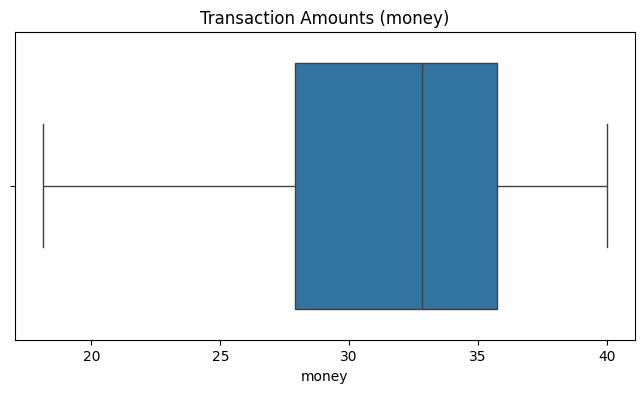

Number of outliers: 0


In [114]:
# Check for exact duplicates
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

#  Check for outliers in 'money' column
# Boxplot to see outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['money'])
plt.title('Transaction Amounts (money)')
plt.show()

# Calculate IQR
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['money'] < lower_bound) | (df['money'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")


There are no duplicated values in the dataset.<br>
From the box plot we can see that there are no visual outliers in the dataset

## 📊 3. Exploratory Data Analysis (EDA)
- Total revenue, average transaction size
- Coffee type distribution (bar plot)
- Transactions by hour ( bar)
- Payment type breakdown (pie chart)
- Revenue trend (time series plot)



In [115]:
# Total revenue
total_revenue = df['money'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}\n")

# Average transaction value
average_transaction = df['money'].mean()
print(f"Average Transaction Size: ${average_transaction:,.2f}\n")


Total Revenue: $115,431.58

Average Transaction Size: $31.75



Total Revenue: $115,431.58<br>

Average Transaction: $31.75

/var/folders/9l/wwc4w0fj57d29jcg35y67n840000gn/T/ipykernel_6436/20594057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='coffee_name', order=df['coffee_name'].value_counts().index, palette='coolwarm')


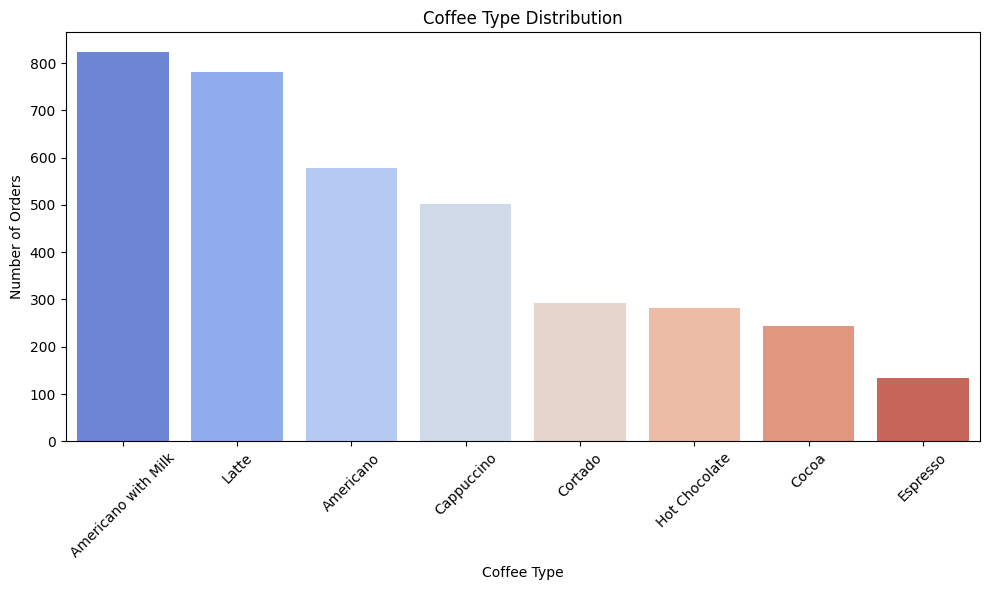

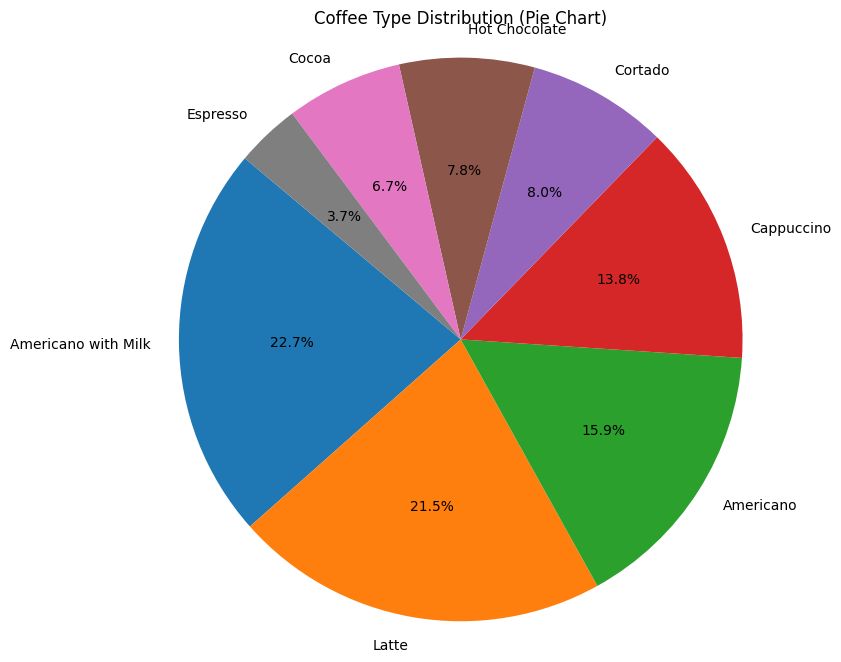

In [116]:
# Coffee type distribution as bar chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='coffee_name', order=df['coffee_name'].value_counts().index, palette='coolwarm')
plt.title('Coffee Type Distribution')
plt.xlabel('Coffee Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart for coffee type distribution
plt.figure(figsize=(8, 8))
df['coffee_name'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Coffee Type Distribution (Pie Chart)')
plt.ylabel('')
plt.axis('equal') 
plt.show()






### Coffee Shop - Comprehensive Coffee Type Distribution Analysis
This analysis combines insights from both the percentage-based pie chart and the absolute number of orders bar chart to provide a holistic view of the popularity of various beverages sold at the coffee shop.

Overall Top Performers:
The data consistently highlights four beverages as the absolute best-sellers, both in terms of percentage of total sales and raw number of orders:

Americano with Milk: This is the clear leader, accounting for 22.7% of all sales and over 800 orders. Its dominance suggests a very strong customer preference for a more mellow, milk-infused Americano.

Latte: A very close second, representing 21.5% of sales and nearly 800 orders (around 780-790). The combined popularity of Americano with Milk and Latte underscores a significant demand for milk-based espresso beverages.

Americano (Black): This classic coffee holds a substantial 15.9% share and approximately 580-590 orders. This indicates a healthy market for traditional black coffee drinkers alongside those who prefer milk.

Cappuccino: Another strong contender, making up 13.8% of sales and around 500 orders. Its consistent performance solidifies the popularity of classic espresso and milk combinations.

These four drinks collectively account for a significant majority of the coffee shop's beverage sales, indicating they are the primary drivers of revenue from this category.

Mid-Range Performers:
These beverages show a moderate level of demand, contributing significantly but not dominating sales:

Cortado: With 8.0% of sales and approximately 290-300 orders, the Cortado caters to a specific segment of customers who likely prefer a stronger, more concentrated milk and espresso drink than a Latte or Cappuccino.

Hot Chocolate: As a non-coffee option, it performs strongly with 7.8% of sales and around 280-290 orders. This highlights its importance for attracting customers who may not drink coffee or prefer a sweet, warm alternative.

Cocoa: Slightly less popular than Hot Chocolate, at 6.7% of sales and about 240-250 orders. While similar to hot chocolate, customers seem to show a distinct preference for the "Hot Chocolate" offering.

Niche or Lowest Volume:
Espresso: This beverage has the smallest share at 3.7% and the lowest number of orders, just under 150. This is typical for coffee shops, as espresso is frequently used as the base for many other popular drinks rather than being ordered neat by the general public. Its low direct sales volume does not diminish its foundational importance to the menu.

/var/folders/9l/wwc4w0fj57d29jcg35y67n840000gn/T/ipykernel_6436/343978978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='month', order=sorted(df['month'].unique()), palette='viridis')


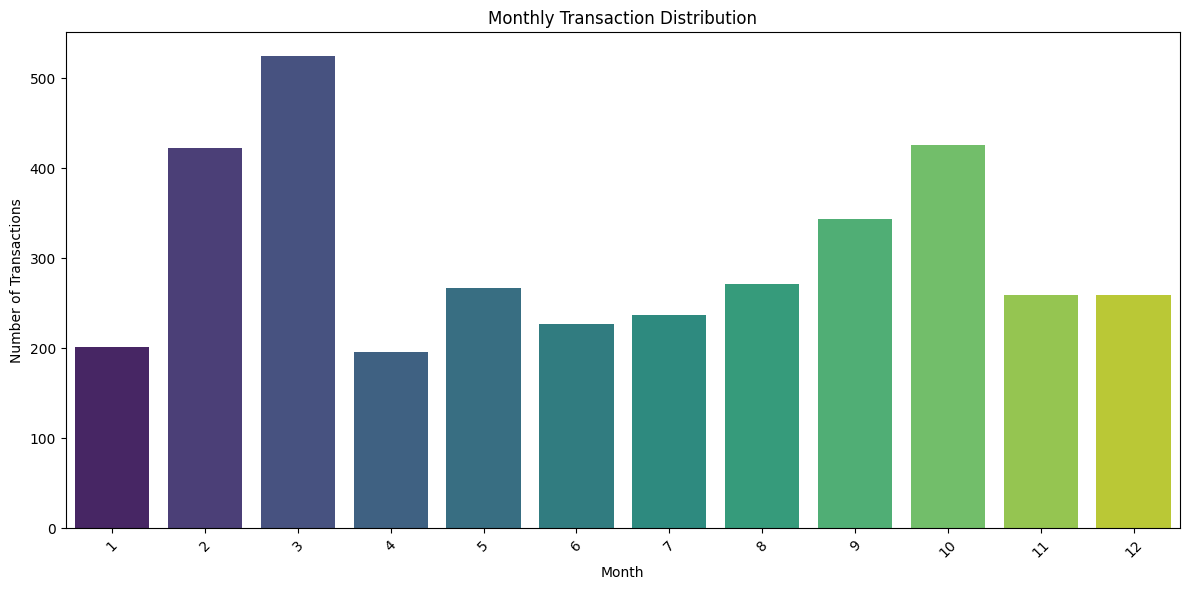

In [117]:
# Monthly transaction distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='month', order=sorted(df['month'].unique()), palette='viridis')
plt.title('Monthly Transaction Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### Monthly Transaction Distribution
The bar chart displays the "Monthly Transaction Distribution," showing the number of transactions for each month of the year.

Peak Transaction Month: March (Month 3) clearly stands out as the month with the highest number of transactions, exceeding 500. This indicates a significant surge in activity during this period.

Second Highest Transaction Month: October (Month 10) records the second-highest number of transactions, around 420-430, suggesting another strong period for transactions.

Lowest Transaction Months: January (Month 1) and April (Month 4) exhibit the lowest transaction volumes, both around 200, indicating a slower start to the year and a dip after the March peak.

Consistent Activity in Latter Half: The latter half of the year (months 8, 9, 10, 11, 12) generally shows a higher and more consistent number of transactions compared to the first half, excluding the March peak.

Steady Growth mid-year: From May (Month 5) to October (Month 10), there's a general upward trend in the number of transactions, with a slight dip in July (Month 7).

End-of-Year Stability: November (Month 11) and December (Month 12) maintain a relatively stable transaction volume, both around 260-270, which is lower than the October peak but higher than the earlier months of the year.

In summary, the chart reveals significant seasonality in transaction volumes, with March being the busiest month and a general increase in activity towards the latter part of the year.

/var/folders/9l/wwc4w0fj57d29jcg35y67n840000gn/T/ipykernel_6436/198409755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weekday', order=sorted(df['weekday'].unique()), palette='Set2')


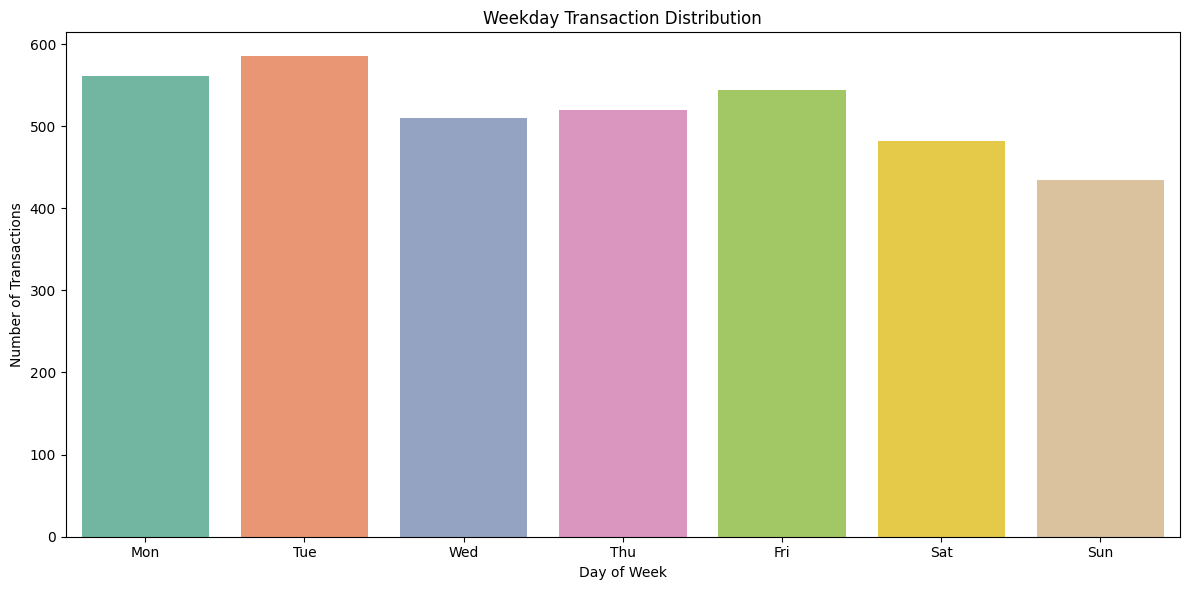

In [118]:
# Weekday transaction distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='weekday', order=sorted(df['weekday'].unique()), palette='Set2')
plt.title('Weekday Transaction Distribution')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.tight_layout()
plt.show()




### Weekday Transaction Distribution
The bar chart titled "Weekday Transaction Distribution" illustrates the number of transactions occurring on each day of the week. Here are the key insights:

Mid-Week Dominance: Tuesday is the busiest day, closely followed by Monday and Friday. This indicates that the core weekdays, particularly the start and end of the traditional work week, drive the most foot traffic and sales.

Consistent Weekday Performance: While Tuesday, Monday, and Friday are top performers, Wednesday and Thursday also maintain strong transaction volumes, only slightly lower than the other weekdays. This suggests a consistent customer base throughout the work week.

Weekend Drop-off: As expected for a business that might cater to a weekday work/commute crowd, transaction volumes decrease significantly on Saturdays and even more so on Sundays. This is a typical pattern for many coffee shops, especially those in business districts.

/var/folders/9l/wwc4w0fj57d29jcg35y67n840000gn/T/ipykernel_6436/1927884063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', order=sorted(df['hour'].unique()), palette='Paired')


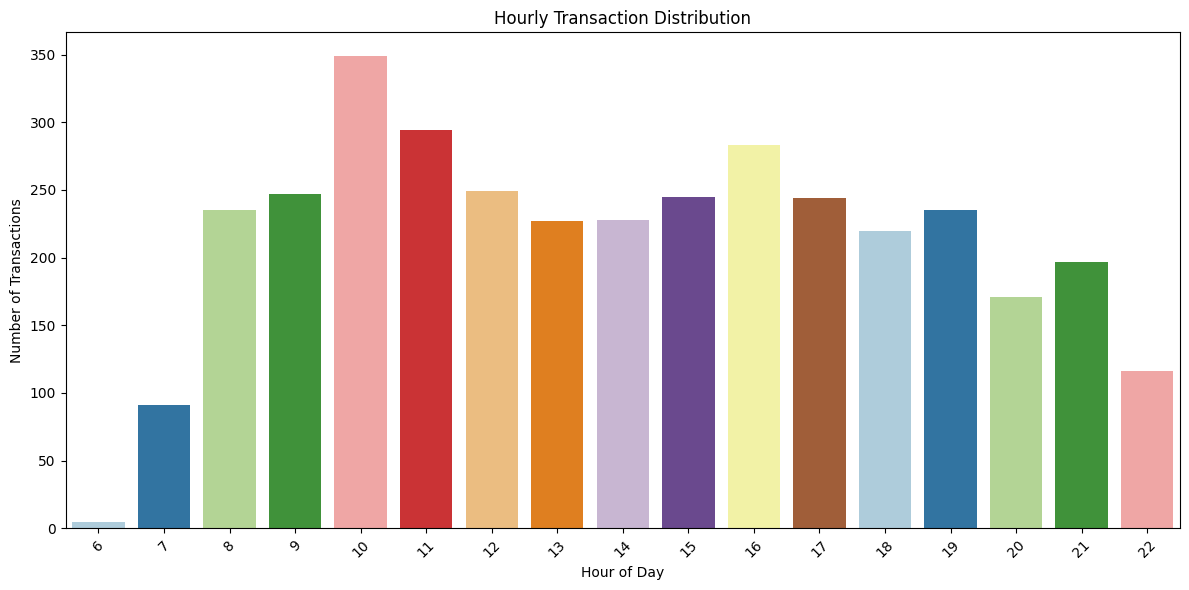

In [119]:
# Hourly transaction distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour', order=sorted(df['hour'].unique()), palette='Paired')
plt.title('Hourly Transaction Distribution')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Hourly Transaction Distribution
The hourly data provides insights into the busiest times of day for the coffee shop:

Morning Rush (Peak): The late morning hours, specifically 10:00 AM and 11:00 AM, represent the absolute peak for transactions. This strongly suggests a significant morning coffee rush, possibly for commuters, office workers on breaks, or morning socializers.

Afternoon Activity: There's a notable resurgence in transactions in the mid-to-late afternoon, particularly around 3:00 PM and 4:00 PM. This could be indicative of an afternoon pick-me-up crowd or post-work/school visits.

Slow Start & Gradual Decline: Transactions are minimal in the early morning (6:00 AM) and gradually increase. After the afternoon peaks, volumes steadily decline into the evening, with a significant drop by 10:00 PM. This reflects the typical operating hours and customer habits for a coffee shop.

Lunchtime Consistency: The period around lunchtime (12:00 PM to 2:00 PM) shows a relatively steady and good volume of transactions, suggesting a consistent flow of customers.

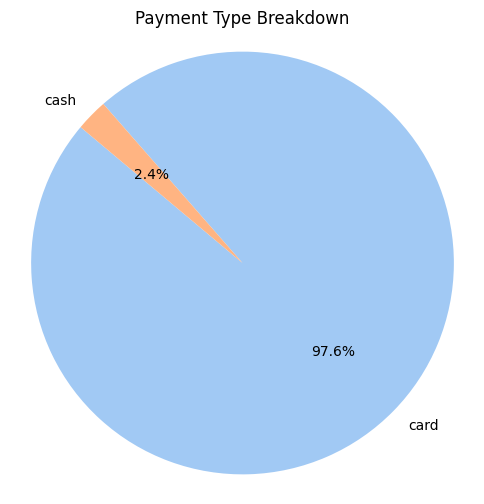

In [120]:
# Payment type breakdown as pie chart
payment_counts = df['cash_type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Type Breakdown')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle.
plt.show()

### Payment Type Breakdown
The payment type data reveals a clear preference for cashless transactions:

Overwhelming Card Preference: An astounding 97.6% of all transactions are made using cards. This indicates that the coffee shop's customer base heavily prefers or relies on electronic payments.

Minimal Cash Usage: Cash transactions account for a minuscule 2.4% of payments. This suggests that the coffee shop could potentially operate with very little physical cash on hand, or that customers rarely choose this option.

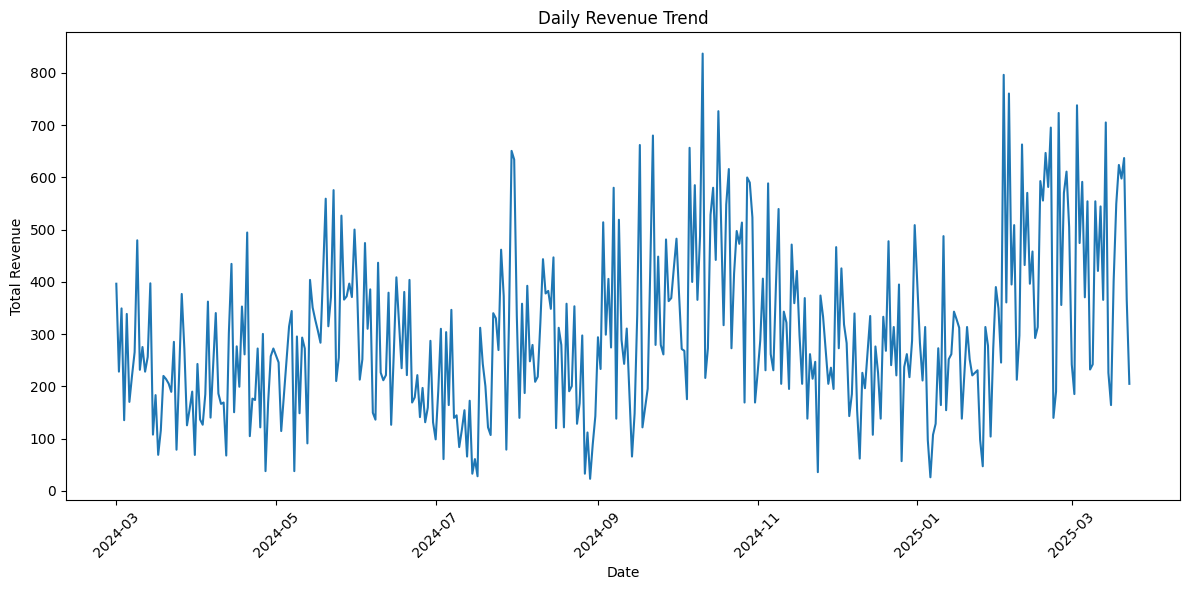

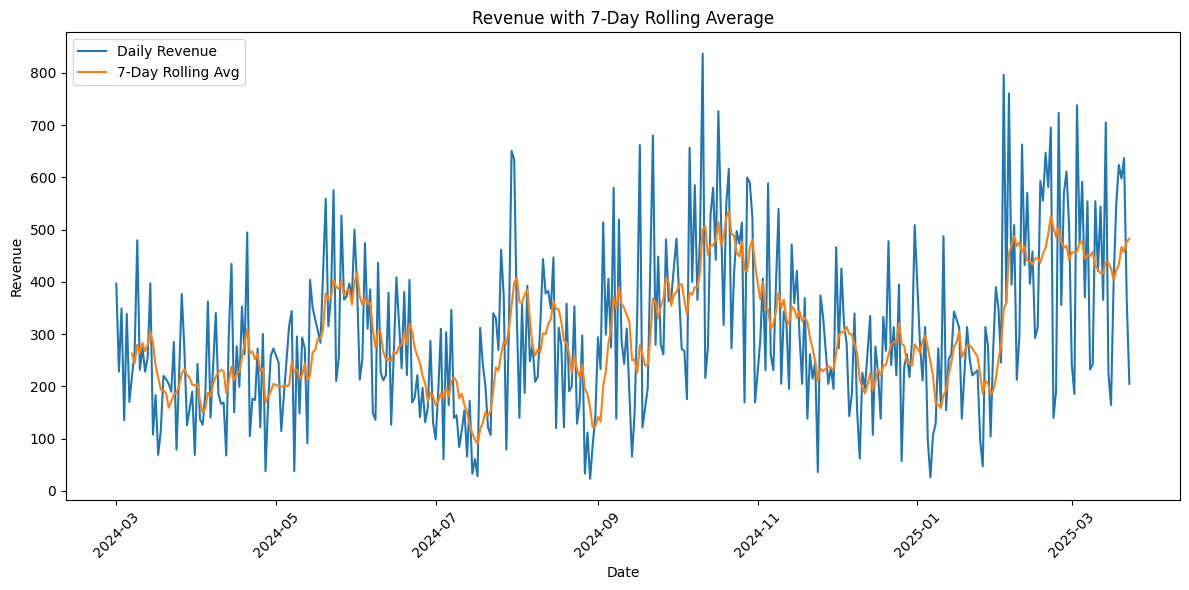

KeyError: 'day_of_week'

In [121]:
# Revenue trend over time

# Daily revenue trend over time
# Group by date
daily_revenue = df.groupby('date')['money'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_revenue, x='date', y='money')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 7-day rolling average of daily revenue
daily_revenue['rolling_avg'] = daily_revenue['money'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_revenue, x='date', y='money', label='Daily Revenue')
sns.lineplot(data=daily_revenue, x='date', y='rolling_avg', label='7-Day Rolling Avg')
plt.title('Revenue with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Heatmap of revenue by day of week and hour
# Group and pivot
heatmap_data = df.groupby(['day_of_week', 'hour'])['money'].sum().reset_index()

# Pivot properly using keyword arguments
pivot_table = heatmap_data.pivot(index='day_of_week', columns='hour', values='money')

# Reorder the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(day_order)




### Coffee Shop - Revenue with 7-Day Rolling Average Analysis
This chart presents the daily revenue alongside a 7-day rolling average, providing a smoother view of the underlying revenue trends by dampening the day-to-day fluctuations.

Key Observations:
Smoothed Trend Identification: The 7-day rolling average (orange line) effectively smooths out the significant daily volatility observed in the "Daily Revenue" (blue line). This makes it much easier to identify underlying trends and periods of sustained higher or lower revenue.

Persistent Fluctuations within Weeks: Even with the rolling average, the daily revenue line shows substantial up-and-down movement around the average. This reinforces the idea of strong weekly cycles (e.g., busier weekdays vs. slower weekends) impacting daily figures.

Periods of Sustained Higher Revenue:

Mid-2024 (Late May to Early July): The rolling average shows a sustained period where revenue trends higher, often around $300-$400, with daily peaks reaching up to $500-$600.

Late Summer/Early Autumn 2024 (Late August to Late November): This period clearly demonstrates a sustained upward trend in the rolling average, peaking around $400-$500, with daily revenues frequently hitting $600-$800. This is the most consistently strong period.

Early 2025 (Mid-January to Mid-March): The rolling average indicates another strong period, maintaining a high level of revenue, often above $400, with daily peaks again surpassing $700-$800.

Periods of Sustained Lower Revenue:

Early March 2024: The beginning of the chart shows a relatively lower rolling average, around $200-$300.

Late July to Mid-August 2024: This period shows a dip in the rolling average, often falling below $200, with some daily revenues dropping very low. This appears to be the lowest sustained period of revenue.

Early January 2025: There's a notable dip in the rolling average right after the new year, indicating a post-holiday slowdown.

Seasonality Confirmed: The rolling average clearly confirms the presence of seasonal patterns. The summer dip (July-August) followed by a stronger autumn and early winter (Sept-Nov/Dec) and another strong period in early spring (Jan-March) suggests that factors like weather, holidays, and academic/work cycles might heavily influence the coffee shop's business.

Impact of Extreme Days: The rolling average helps to put extreme daily peaks and troughs into perspective. While some days may have very high or very low revenue, the average indicates that these could be isolated incidents or part of a broader trend.



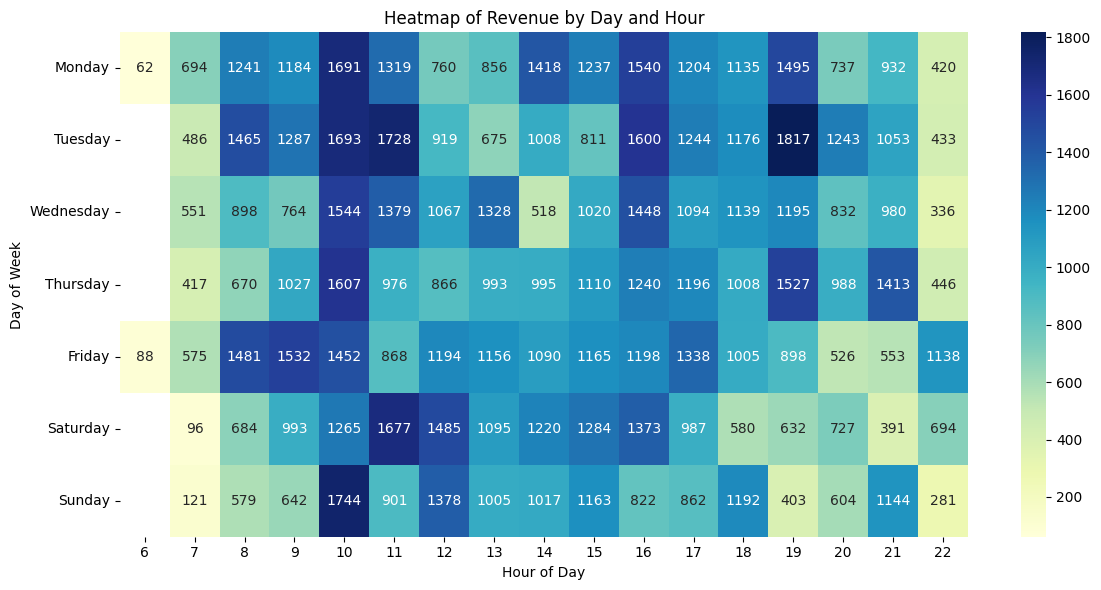

In [ ]:
# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Heatmap of Revenue by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


### Coffee Shop - Heatmap of Revenue by Day and Hour Analysis
This heatmap provides a detailed breakdown of the coffee shop's revenue, categorized by the day of the week and the hour of the day. The color intensity, along with the numerical values, indicates the level of revenue, allowing for precise identification of peak and low revenue periods.

Key Insights:
Overall Revenue Patterns:

Dominant Morning/Mid-Day Peaks: The most prominent high-revenue periods consistently fall between 9 AM and 11 AM across almost all weekdays. This indicates a strong morning and pre-lunch rush.

Afternoon Resurgence: Many days also show a second, albeit often smaller, surge in revenue in the late afternoon/early evening, particularly between 3 PM and 6 PM (15:00 and 18:00).

Early Morning & Late Evening Lull: Revenue is significantly lower in the early morning (6 AM - 7 AM) and generally declines after 8 PM (20:00).

Weekday Specific Trends:

Tuesday is King: Tuesday consistently shows some of the highest revenue figures, with 1 PM (13:00) ($1817) and 10 AM (10:00) ($1693) being particularly strong. This reinforces its position as the busiest day.

Monday & Friday Strong Start/End: Monday (especially 10 AM with $1691) and Friday (with $1532 at 10 AM and $1481 at 9 AM) also exhibit very high morning peaks, indicating strong activity at the beginning and end of the work week.

Mid-Week Peaks (Wed/Thu): Wednesday and Thursday also have strong morning peaks (e.g., Wednesday 10 AM at $1544, Thursday 10 AM at $1627). They generally show high revenue during typical lunch hours as well (12 PM - 2 PM).

Afternoon Peaks on Weekdays: Many weekdays show significant afternoon revenue. For instance, Tuesday at 6 PM (18:00) reaches $1817, Monday at 5 PM (17:00) hits $1540, and Thursday at 7 PM (19:00) reaches $1527.

Weekend Trends:

Later Peaks on Weekends: Unlike weekdays, Saturday and Sunday see their highest revenue hours slightly later in the day, primarily from 10 AM to 1 PM (13:00). Saturday's peak is at 11 AM ($1677), and Sunday's is at 12 PM ($1744). This aligns with a more relaxed weekend schedule.

Sustained Weekend Afternoons: Weekends maintain relatively good revenue into the afternoon (until around 4 PM - 16:00), though generally lower than weekday peaks.

Sunday Afternoon Dip: Sunday shows a sharper drop in revenue in the late afternoon/evening compared to other days.

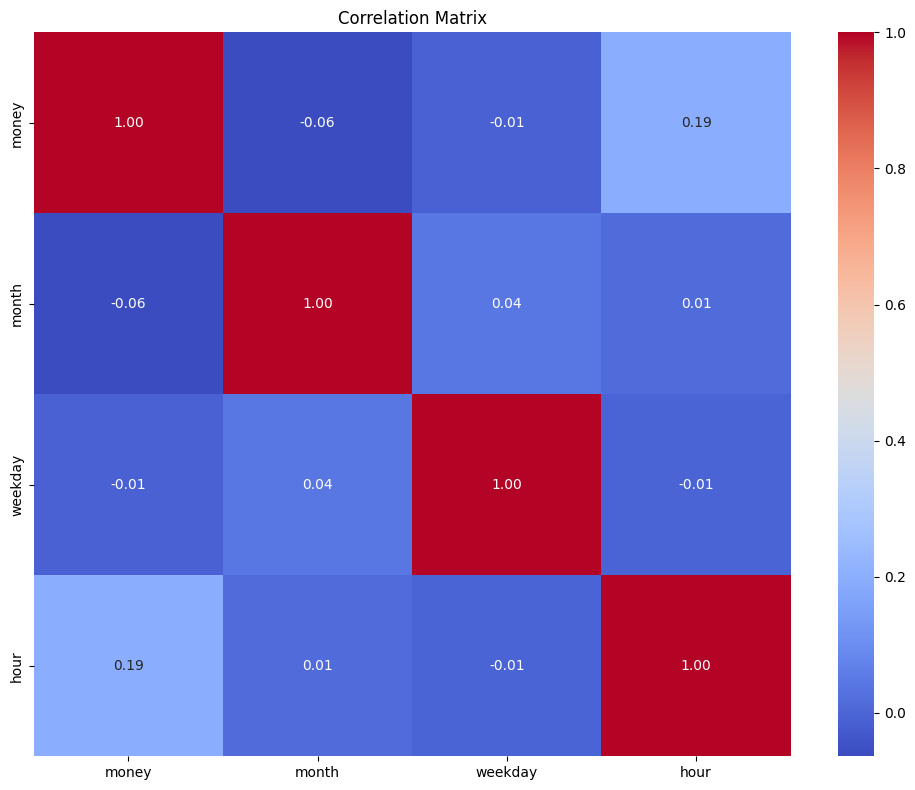

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Correlation Matrix Explanation
This heatmap displays the Pearson correlation coefficients between different variables related to coffee shop transactions: 'money' (representing revenue or transaction amount), 'month', 'weekday', and 'hour'.



Key Insights from the Matrix:
Money and Money (Diagonal):

The diagonal elements are all 1.00. This is expected, as a variable is perfectly correlated with itself.

Money and Month:

Correlation coefficient: -0.06

This indicates a very weak, slightly negative linear correlation between the amount of 'money' (revenue/transaction amount) and the 'month' of the year. In practical terms, this value is so close to zero that it suggests no significant linear relationship between the month and the amount of money generated. This is an interesting finding, considering the "Monthly Transaction Distribution" chart showed distinct peaks and troughs in transaction count. This might imply that while the number of transactions changes by month, the average revenue per transaction or total daily revenue isn't strongly linearly influenced by the month itself, or that the monthly variations are not strictly linear.

Money and Weekday:

Correlation coefficient: -0.01

This value is extremely close to zero, indicating virtually no linear correlation between 'money' and the 'weekday'. This is also a surprising finding, as the "Weekday Transaction Distribution" clearly showed higher transaction counts on weekdays compared to weekends. This low correlation suggests that while the volume of transactions changes, the average revenue per transaction or total daily revenue is not linearly correlated with which specific day of the week it is. It might be that higher volume days have lower average transaction values, or vice versa, balancing out the revenue.

Money and Hour:

Correlation coefficient: 0.19

This shows a weak positive linear correlation between 'money' and the 'hour' of the day. While weak, it's the strongest correlation with 'money' among the time variables. This suggests that as the 'hour' progresses through the day, there's a slight tendency for 'money' to increase, which aligns with the "Hourly Transaction Distribution" showing higher transaction volumes in mid-morning and afternoon, leading to higher revenue.


Conclusion:
The correlation matrix suggests that for this dataset:

The 'money' variable (individual transaction value) has a very weak to negligible linear relationship with 'month' and 'weekday'. This might imply that on days/months with higher transaction counts, the average value per transaction could be lower, or vice-versa, masking a linear relationship in total 'money'.

There's a weak positive linear relationship with 'hour', meaning as the day progresses, there's a slight tendency for 'money' to increase, which makes sense with the morning/afternoon peaks.

The temporal variables (month, weekday, hour) are largely independent of each other, as expected.

Important Note: Correlation measures linear relationships. The lack of a strong linear correlation does not mean there's no relationship at all, especially for time-based data which often exhibits non-linear patterns. For instance, while 'money' and 'weekday' have a near-zero linear correlation, we know from the "Weekday Transaction Distribution" that certain weekdays generate far more transactions (and likely more total revenue) than others. This suggests the relationships in this dataset is more complex than a simple linear one.

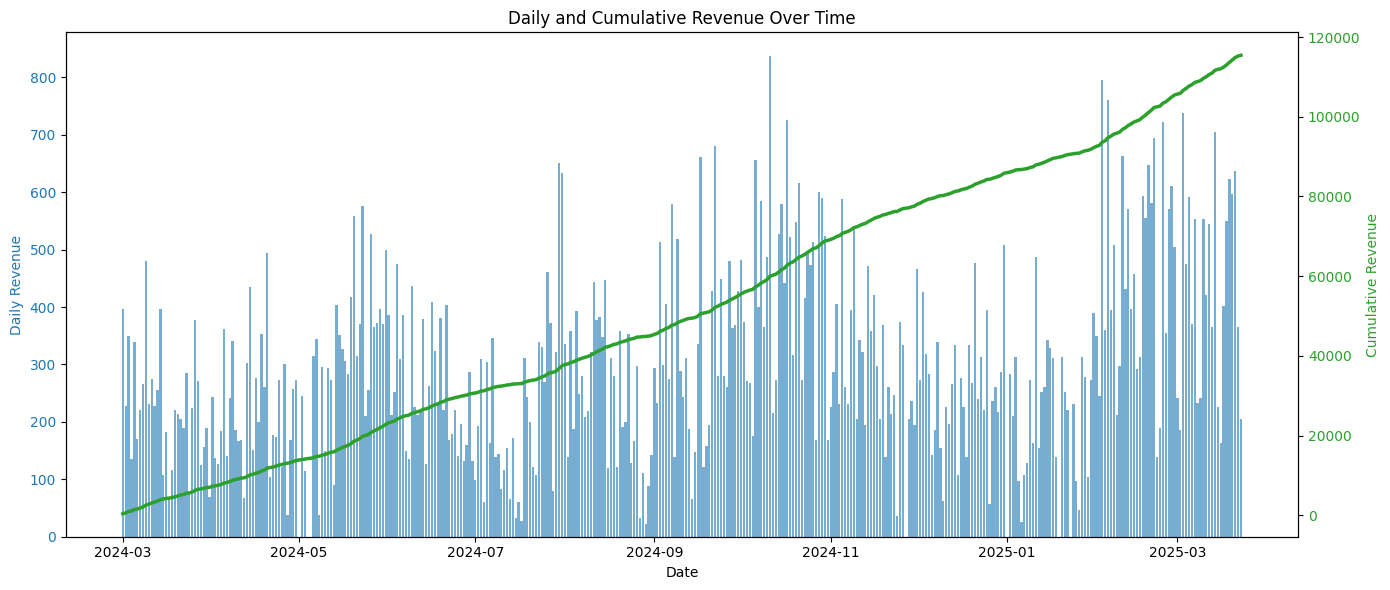

In [ ]:

# Cumulative revenue over time and daily revenue plot
# Group by date
daily_sales = df.groupby('date')['money'].sum().reset_index()
daily_sales['cumulative_revenue'] = daily_sales['money'].cumsum()

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot daily revenue
color1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Revenue', color=color1)
ax1.bar(daily_sales['date'], daily_sales['money'], color=color1, alpha=0.6, label='Daily Revenue')
ax1.tick_params(axis='y', labelcolor=color1)

# Create second y-axis
ax2 = ax1.twinx()

# Plot cumulative revenue
color2 = 'tab:green'
ax2.set_ylabel('Cumulative Revenue', color=color2)
ax2.plot(daily_sales['date'], daily_sales['cumulative_revenue'], color=color2, linewidth=2.5, label='Cumulative Revenue')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and formatting
plt.title('Daily and Cumulative Revenue Over Time')
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()


## 📈 4. Key Insights
- Best-selling product(s)
- Peak business times
- Preferred payment methods

## 📌 5. Conclusion
Short summary of findings + any suggestions

## 💡 6. Next Steps (optional)
Ideas for future work (e.g., linking with inventory or customer data)